<a href="https://colab.research.google.com/github/Jbaner/OMDSModC_Capstone_Project/blob/main/OMDS_ModC_Week4_Banerjee_Jayeeta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score,recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay,confusion_matrix,classification_report,RocCurveDisplay
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [26]:
datasource= "https://archive.ics.uci.edu/static/public/17/data.csv"

df_BreastCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
df_BreastCancer.sample(10, random_state=42) #printing random sample of 10 rows

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
204,87930,12.47,18.60,81.09,481.9,0.09965,0.10580,0.08005,0.03821,0.1925,...,24.64,96.05,677.9,0.14260,0.2378,0.2671,0.10150,0.3014,0.08750,B
70,859575,18.94,21.31,123.60,1130.0,0.09009,0.10290,0.10800,0.07951,0.1582,...,26.58,165.90,1866.0,0.11930,0.2336,0.2687,0.17890,0.2551,0.06589,M
131,8670,15.46,19.48,101.70,748.9,0.10920,0.12230,0.14660,0.08087,0.1931,...,26.00,124.90,1156.0,0.15460,0.2394,0.3791,0.15140,0.2837,0.08019,M
431,907915,12.40,17.68,81.47,467.8,0.10540,0.13160,0.07741,0.02799,0.1811,...,22.91,89.61,515.8,0.14500,0.2629,0.2403,0.07370,0.2556,0.09359,B
540,921385,11.54,14.44,74.65,402.9,0.09984,0.11200,0.06737,0.02594,0.1818,...,19.68,78.78,457.8,0.13450,0.2118,0.1797,0.06918,0.2329,0.08134,B
567,927241,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.8681,0.9387,0.26500,0.4087,0.12400,M
369,9012000,22.01,21.90,147.20,1482.0,0.10630,0.19540,0.24480,0.15010,0.1824,...,25.80,195.00,2227.0,0.12940,0.3885,0.4756,0.24320,0.2741,0.08574,M
29,853201,17.57,15.05,115.00,955.1,0.09847,0.11570,0.09875,0.07953,0.1739,...,19.52,134.90,1227.0,0.12550,0.2812,0.2489,0.14560,0.2756,0.07919,M
81,8611161,13.34,15.86,86.49,520.0,0.10780,0.15350,0.11690,0.06987,0.1942,...,23.19,96.66,614.9,0.15360,0.4791,0.4858,0.17080,0.3527,0.10160,B
477,911673,13.90,16.62,88.97,599.4,0.06828,0.05319,0.02224,0.01339,0.1813,...,21.80,101.20,718.9,0.09384,0.2006,0.1384,0.06222,0.2679,0.07698,B


In [27]:
df_BreastCancer["Diagnosis"]=df_BreastCancer["Diagnosis"].map({"M":0, "B":1})

In [28]:

#Target and Features
X= df_BreastCancer.drop(["Diagnosis","ID"], axis=1)
y= df_BreastCancer["Diagnosis"]
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42)

In [29]:
#Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled =  scaler.transform(X_test)

model = LogisticRegression(max_iter = 5000, random_state = 42)
model.fit(X_train_scaled, y_train)

#Prediction
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

#Evaluation
accuracy_score = accuracy_score(y_test, y_pred)
precision_score = precision_score(y_test, y_pred)
recall_score = recall_score(y_test, y_pred)
f1_score = f1_score(y_test, y_pred)
roc_auc_score = roc_auc_score(y_test, y_pred)
print("Accuracy:",accuracy_score)
print("Precision:",precision_score)
print("Recall:", recall_score)
print("F1 score:", f1_score)
print("ROC AUC: ", roc_auc_score)


cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)
print("\nConfusion Matrix: \n", cm)
print("\nClassification Report: \n\n", cr)


Accuracy: 0.9790209790209791
Precision: 0.9886363636363636
Recall: 0.9775280898876404
F1 score: 0.9830508474576272
ROC AUC:  0.9795047856845609

Confusion Matrix: 
 [[53  1]
 [ 2 87]]

Classification Report: 

               precision    recall  f1-score   support

           0       0.96      0.98      0.97        54
           1       0.99      0.98      0.98        89

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



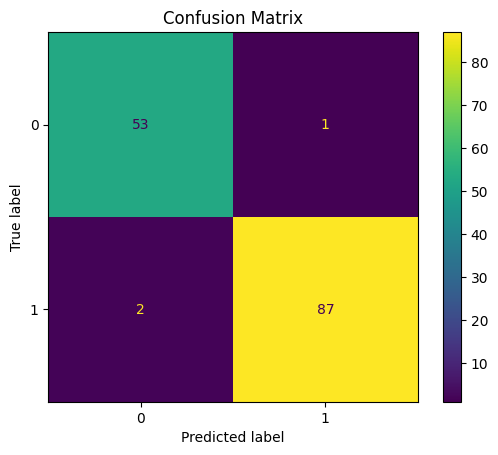

In [30]:
#Confusion Matrix
ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, y_test)
plt.title("Confusion Matrix")
plt.show()



               Feature  Coefficient
21            texture3    -1.302299
10             radius2    -1.286492
28           symmetry3    -1.226697
7      concave_points1    -1.088011
26          concavity3    -1.006375
13               area2    -0.895123
20             radius3    -0.846302
23               area3    -0.822258
27     concave_points3    -0.775197
6           concavity1    -0.735499
19  fractal_dimension2     0.729363
15        compactness2     0.636886
5         compactness1     0.617008
12          perimeter2    -0.592756
24         smoothness3    -0.530838


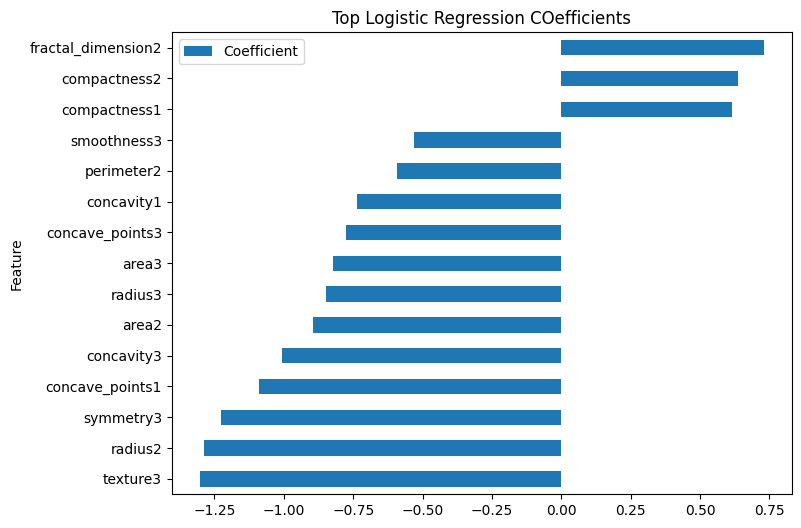

In [31]:
#Feature Impotance
coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_[0]})
coef_df = coef_df.sort_values("Coefficient", key=abs, ascending=False)
print(coef_df.head(15))

coef_df.head(15).sort_values("Coefficient").plot(x="Feature", y="Coefficient", kind="barh", figsize=(8,6))
plt.title("Top Logistic Regression COefficients")
plt.show()


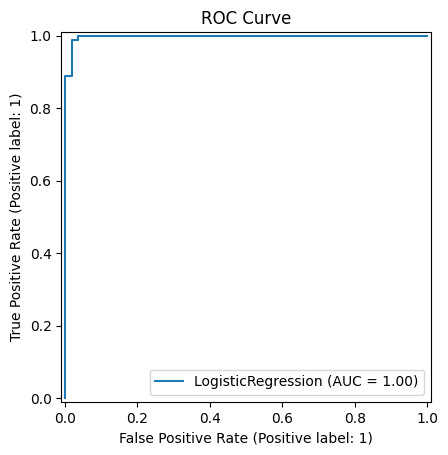

In [32]:
#ROC curve
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)
plt.title("ROC Curve")
plt.show()


In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5-Fold Cross Validation Setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression(max_iter=5000, random_state=42)
cv_scores = cross_validate(
    model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring={
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc'})

# CV Results
print("5-Fold Cross Validation Results (Logistic Regression)")
print("-----------------------------------------------------")
print("Accuracy :", cv_scores['test_accuracy'].mean())
print("Precision:", cv_scores['test_precision'].mean())
print("Recall   :", cv_scores['test_recall'].mean())
print("F1 Score :", cv_scores['test_f1'].mean())
print("ROC AUC  :", cv_scores['test_roc_auc'].mean())

# Train Final Model
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Test Evaluation
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\nTest Set Results")
print("----------------")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)
print("ROC AUC  :", roc_auc)

# Confusion Matrix and Report
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n\n", cr)

5-Fold Cross Validation Results (Logistic Regression)
-----------------------------------------------------
Accuracy : 0.9764705882352942
Precision: 0.9705863599677158
Recall   : 0.9919871794871795
F1 Score : 0.9809926184926185
ROC AUC  : 0.9939147082004226

Test Set Results
----------------
Accuracy : 0.9790209790209791
Precision: 0.9886363636363636
Recall   : 0.9775280898876404
F1 Score : 0.9830508474576272
ROC AUC  : 0.9977111943404079

Confusion Matrix:
 [[53  1]
 [ 2 87]]

Classification Report:

               precision    recall  f1-score   support

           0       0.96      0.98      0.97        54
           1       0.99      0.98      0.98        89

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



               Feature  Coefficient  Abs_Coeff
21            texture3    -1.302299   1.302299
10             radius2    -1.286492   1.286492
28           symmetry3    -1.226697   1.226697
7      concave_points1    -1.088011   1.088011
26          concavity3    -1.006375   1.006375
13               area2    -0.895123   0.895123
20             radius3    -0.846302   0.846302
23               area3    -0.822258   0.822258
27     concave_points3    -0.775197   0.775197
6           concavity1    -0.735499   0.735499
19  fractal_dimension2     0.729363   0.729363
15        compactness2     0.636886   0.636886
5         compactness1     0.617008   0.617008
12          perimeter2    -0.592756   0.592756
24         smoothness3    -0.530838   0.530838


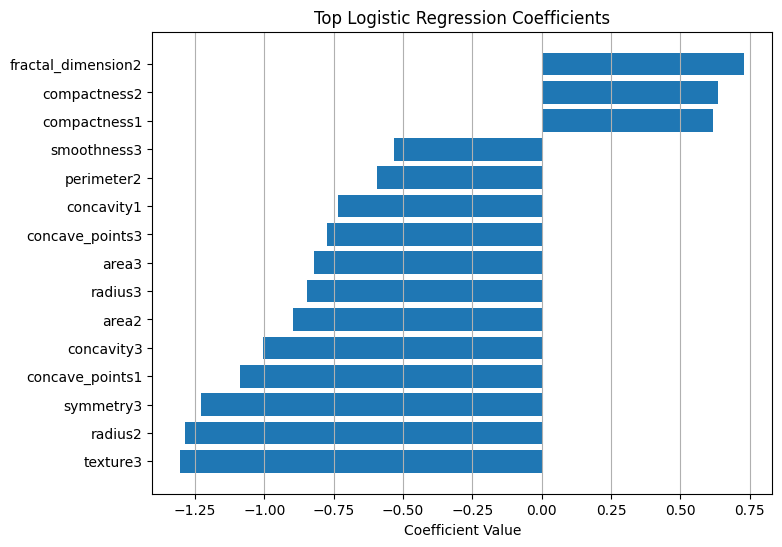

In [34]:
import matplotlib.pyplot as plt
# Feature importance (Logistic Regression coefficients)
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]})

# Sort by absolute importance
coef_df["Abs_Coeff"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Abs_Coeff", ascending=False)
print(coef_df.head(15))

# Plot Top 15 Features
top_features = coef_df.head(15).sort_values("Coefficient")
plt.figure(figsize=(8,6))
plt.barh(top_features["Feature"], top_features["Coefficient"])

plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.grid(axis='x')
plt.show()

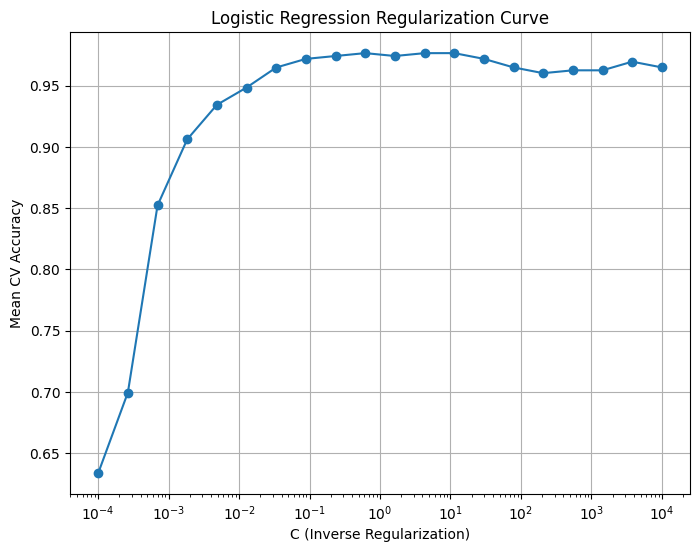

In [35]:
from sklearn.model_selection import cross_val_score
C_values = np.logspace(-4, 4, 20)
cv_accuracy = []

for c in C_values:
    model = LogisticRegression(
        C=c,
        max_iter=5000,
        random_state=42)

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='accuracy')

    cv_accuracy.append(scores.mean())

plt.figure(figsize=(8,6))
plt.semilogx(C_values, cv_accuracy, marker='o')
plt.xlabel("C (Inverse Regularization)")
plt.ylabel("Mean CV Accuracy")
plt.title("Logistic Regression Regularization Curve")
plt.grid(True)
plt.show()

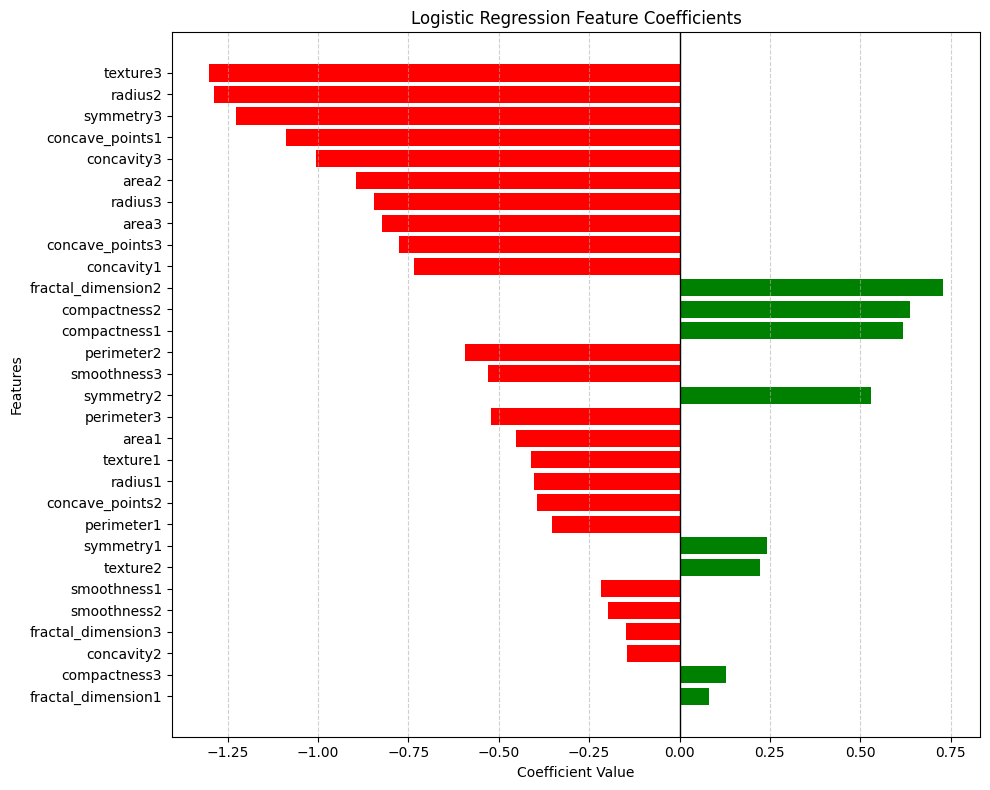

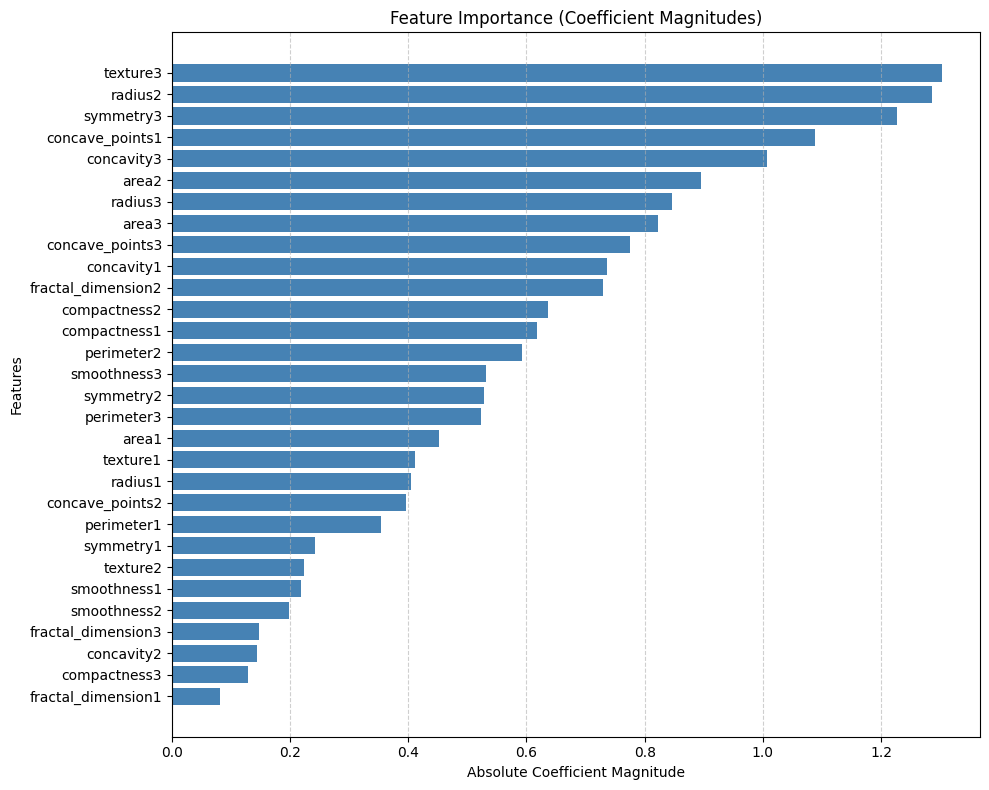

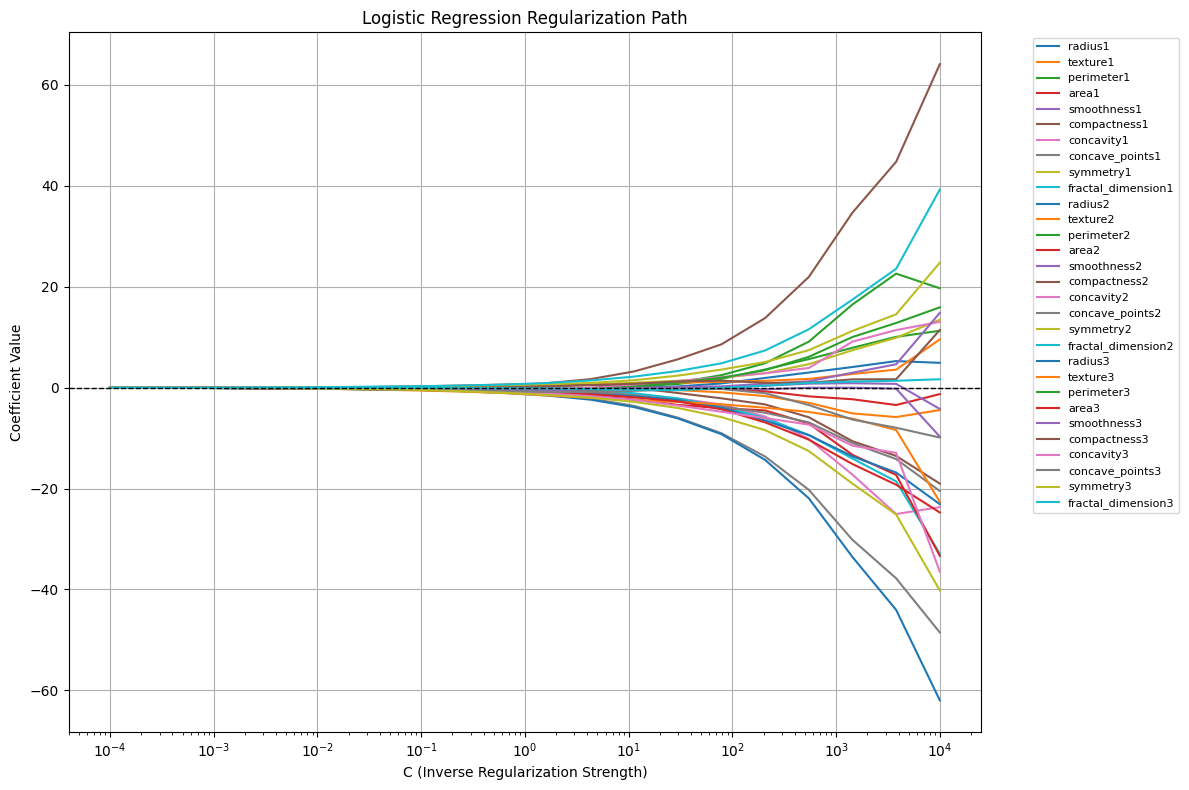

In [36]:
# Logistic Regression Coefficient Magnitude Plot

# Train the model
model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train_scaled, y_train)

# Create a DataFrame of coefficients
coef_df = pd.DataFrame({
    "Feature": X_train.columns,      # Replace with your feature names if needed
    "Coefficient": model.coef_[0]})

# Compute absolute coefficient values
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
# Sort by importance
coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False)

# Plot Signed Coefficients
colors = ["green" if x > 0 else "red" for x in coef_df["Coefficient"]]

plt.figure(figsize=(10, 8))
plt.barh(
    coef_df["Feature"],
    coef_df["Coefficient"],
    color=colors)

plt.axvline(x=0, color="black", linewidth=1)
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.title("Logistic Regression Feature Coefficients")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Plot Absolute Coefficient Magnitudes
plt.figure(figsize=(10, 8))
plt.barh(
    coef_df["Feature"],
    coef_df["Abs_Coefficient"],
    color="steelblue")

plt.xlabel("Absolute Coefficient Magnitude")
plt.ylabel("Features")
plt.title("Feature Importance (Coefficient Magnitudes)")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Regularization Path
C_values = np.logspace(-4, 4, 20)
coef_path = []
for C in C_values:
    lr = LogisticRegression(
        C=C,
        max_iter=5000,
        random_state=42)
    lr.fit(X_train_scaled, y_train)
    coef_path.append(lr.coef_[0])
coef_path = np.array(coef_path)

plt.figure(figsize=(12, 8))
for i, feature in enumerate(X_train.columns):
    plt.semilogx(C_values, coef_path[:, i], label=feature)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("C (Inverse Regularization Strength)")
plt.ylabel("Coefficient Value")
plt.title("Logistic Regression Regularization Path")
plt.grid(True)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8)
plt.tight_layout()
plt.show()

In [37]:
datasource= "https://archive.ics.uci.edu/static/public/383/data.csv"

df_CivicalCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
df_CivicalCancer.sample(10, random_state=42) #printing random sample of 10 rows

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
713,16,1.0,16.0,1.0,0.0,0.0,0.000,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
604,23,3.0,17.0,2.0,0.0,0.0,0.000,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
120,33,1.0,16.0,4.0,0.0,0.0,0.000,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
208,27,4.0,16.0,1.0,0.0,0.0,0.000,1.0,0.67,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
380,18,3.0,15.0,1.0,1.0,2.0,0.003,1.0,0.58,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
813,20,1.0,17.0,NaN,0.0,0.0,0.000,1.0,1.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
575,17,2.0,15.0,1.0,0.0,0.0,0.000,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
266,21,2.0,19.0,1.0,0.0,0.0,0.000,1.0,1.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
557,27,2.0,17.0,3.0,0.0,0.0,0.000,1.0,0.25,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
822,36,3.0,20.0,2.0,0.0,0.0,0.000,1.0,6.00,0.0,...,16.0,16.0,1,0,1,1,0,0,0,0


In [38]:
df_CivicalCancer = df_CivicalCancer.drop(columns=[
    "STDs: Time since first diagnosis",
    "STDs: Time since last diagnosis",
    "STDs:cervical condylomatosis",
    "STDs:AIDS"
])
binary_cols = ["Smokes (packs/year)", "IUD (years)", "STDs (number)", "Hormonal Contraceptives (years)"]
df_CivicalCancer[binary_cols] = df_CivicalCancer[binary_cols].fillna(0)

#df_CivicalCancer[num_cols] = df_CivicalCancer[num_cols].fillna(df_CivicalCancer[num_cols].median())
df_CivicalCancer["Number of sexual partners"] = df_CivicalCancer["Number of sexual partners"].fillna(df_CivicalCancer["Number of sexual partners"].median())
df_CivicalCancer["Num of pregnancies"] = df_CivicalCancer["Num of pregnancies"].fillna(df_CivicalCancer["Num of pregnancies"].median())
df_CivicalCancer["First sexual intercourse"] = df_CivicalCancer["First sexual intercourse"].fillna(df_CivicalCancer["First sexual intercourse"].median())
df_CivicalCancer["Smokes (packs/year)"] = df_CivicalCancer["Smokes (packs/year)"].fillna(df_CivicalCancer["Smokes (packs/year)"].median())
df_CivicalCancer["IUD (years)"] = df_CivicalCancer["IUD (years)"].fillna(df_CivicalCancer["IUD (years)"].median())
df_CivicalCancer["STDs (number)"] = df_CivicalCancer["STDs (number)"].fillna(df_CivicalCancer["STDs (number)"].median())
df_CivicalCancer["STDs: Number of diagnosis"] = df_CivicalCancer["STDs: Number of diagnosis"].fillna(df_CivicalCancer["STDs: Number of diagnosis"].median())

df_CivicalCancer["Hormonal Contraceptives (years)"] = df_CivicalCancer["Hormonal Contraceptives (years)"].fillna(df_CivicalCancer["Hormonal Contraceptives (years)"].median())
df_CivicalCancer["STDs:condylomatosis"] = df_CivicalCancer["STDs:condylomatosis"].fillna(df_CivicalCancer["STDs:condylomatosis"].median())
#df_CivicalCancer["STDs:cervical condylomatosis"] = df_CivicalCancer["STDs:cervical condylomatosis"].fillna(df_CivicalCancer["STDs:cervical condylomatosis"].median())
df_CivicalCancer["STDs:vulvo-perineal condylomatosis"] = df_CivicalCancer["STDs:vulvo-perineal condylomatosis"].fillna(df_CivicalCancer["STDs:vulvo-perineal condylomatosis"].median())
df_CivicalCancer["STDs:syphilis"] = df_CivicalCancer["STDs:syphilis"].fillna(df_CivicalCancer["STDs:syphilis"].median())
df_CivicalCancer["STDs:pelvic inflammatory disease"] = df_CivicalCancer["STDs:pelvic inflammatory disease"].fillna(df_CivicalCancer["STDs:pelvic inflammatory disease"].median())
df_CivicalCancer["STDs:genital herpes"] = df_CivicalCancer["STDs:genital herpes"].fillna(df_CivicalCancer["STDs:genital herpes"].median())
df_CivicalCancer["STDs:molluscum contagiosum"] = df_CivicalCancer["STDs:molluscum contagiosum"].fillna(df_CivicalCancer["STDs:molluscum contagiosum"].median())
#df_CivicalCancer["STDs:AIDS"] = df_CivicalCancer["STDs:AIDS"].fillna(df_CivicalCancer["STDs:AIDS"].median())
df_CivicalCancer["STDs:Hepatitis B"] = df_CivicalCancer["STDs:Hepatitis B"].fillna(df_CivicalCancer["STDs:Hepatitis B"].median())
df_CivicalCancer["STDs:HPV"] = df_CivicalCancer["STDs:HPV"].fillna(df_CivicalCancer["STDs:HPV"].median())

df_CivicalCancer["Dx:HPV"] = df_CivicalCancer["Dx:HPV"].fillna(df_CivicalCancer["Dx:HPV"].mode())
df_CivicalCancer["Dx:CIN"] = df_CivicalCancer["Dx:CIN"].fillna(df_CivicalCancer["Dx:CIN"].mode())
df_CivicalCancer["Dx:Cancer"] = df_CivicalCancer["Dx:CIN"].fillna(df_CivicalCancer["Dx:Cancer"].mode())

df_CivicalCancer_nw= df_CivicalCancer[["Age","Number of sexual partners","First sexual intercourse",
                 "Num of pregnancies","Smokes (packs/year)","Hormonal Contraceptives (years)","IUD (years)","STDs (number)","STDs: Number of diagnosis",
                                    "STDs:condylomatosis", "STDs:vulvo-perineal condylomatosis",
                                    "STDs:syphilis","STDs:pelvic inflammatory disease","STDs:genital herpes",
                                    "STDs:molluscum contagiosum","STDs:Hepatitis B","STDs:HPV", "Biopsy"]]



In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
#Target and Features
X= df_CivicalCancer_nw.drop(["Biopsy"], axis=1)
y= df_CivicalCancer_nw["Biopsy"]
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42)

In [40]:
#Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled =  scaler.transform(X_test)

model = LogisticRegression(max_iter = 5000, random_state = 42)
model.fit(X_train_scaled, y_train)

#Prediction
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

#Evaluation
accuracy_score = accuracy_score(y_test, y_pred)
precision_score = precision_score(y_test, y_pred)
recall_score = recall_score(y_test, y_pred)
f1_score = f1_score(y_test, y_pred)
roc_auc_score = roc_auc_score(y_test, y_pred)
print("Accuracy:",accuracy_score)
print("Precision:",precision_score)
print("Recall:", recall_score)
print("F1 score:", f1_score)
print("ROC AUC: ", roc_auc_score)


cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)
print("\nConfusion Matrix: \n", cm)
print("\nClassification Report: \n\n", cr)


Accuracy: 0.9441860465116279
Precision: 0.0
Recall: 0.0
F1 score: 0.0
ROC AUC:  0.5

Confusion Matrix: 
 [[203   0]
 [ 12   0]]

Classification Report: 

               precision    recall  f1-score   support

           0       0.94      1.00      0.97       203
           1       0.00      0.00      0.00        12

    accuracy                           0.94       215
   macro avg       0.47      0.50      0.49       215
weighted avg       0.89      0.94      0.92       215



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

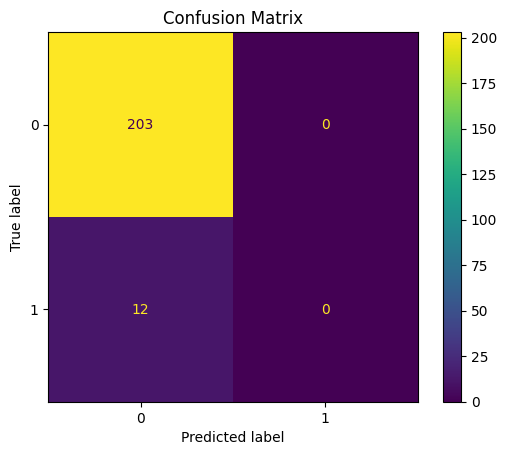

In [41]:
#Confusion Matrix
ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, y_test)
plt.title("Confusion Matrix")
plt.show()

                               Feature  Coefficient
11                       STDs:syphilis    -0.588454
7                        STDs (number)     0.563150
9                  STDs:condylomatosis    -0.321858
13                 STDs:genital herpes     0.253302
0                                  Age     0.250862
12    STDs:pelvic inflammatory disease    -0.147817
16                            STDs:HPV    -0.142655
14          STDs:molluscum contagiosum    -0.141516
5      Hormonal Contraceptives (years)     0.098784
4                  Smokes (packs/year)    -0.074695
6                          IUD (years)    -0.069830
2             First sexual intercourse    -0.062083
10  STDs:vulvo-perineal condylomatosis     0.059735
8            STDs: Number of diagnosis     0.055170
1            Number of sexual partners     0.051276


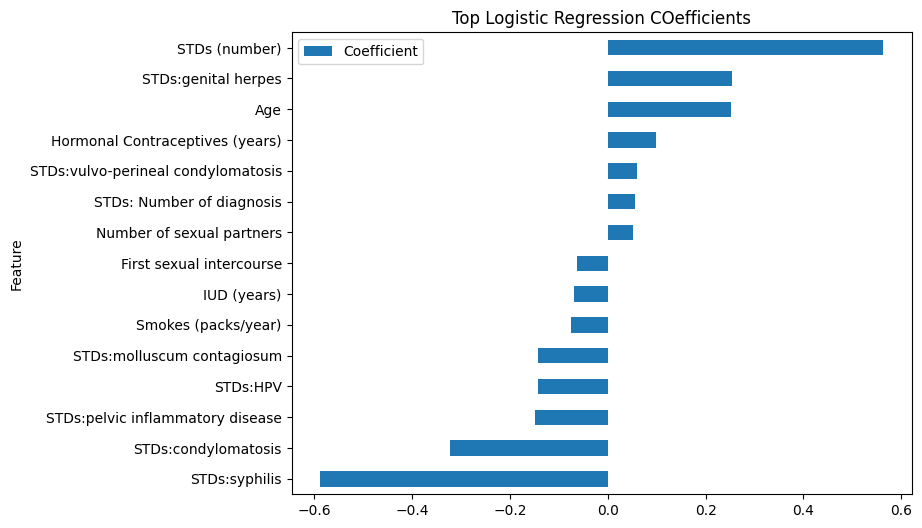

In [42]:
#Feature Impotance
coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_[0]})
coef_df = coef_df.sort_values("Coefficient", key=abs, ascending=False)
print(coef_df.head(15))

coef_df.head(15).sort_values("Coefficient").plot(x="Feature", y="Coefficient", kind="barh", figsize=(8,6))
plt.title("Top Logistic Regression COefficients")
plt.show()

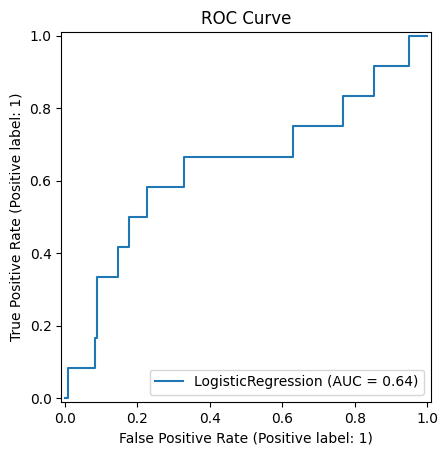

In [43]:
#ROC curve
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)
plt.title("ROC Curve")
plt.show()

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5-Fold Cross Validation Setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression(max_iter=5000, random_state=42)

cv_scores = cross_validate(
    model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring={
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc'})

# CV Results
print("5-Fold Cross Validation Results (Logistic Regression)")
print("-----------------------------------------------------")
print("Accuracy :", cv_scores['test_accuracy'].mean())
print("Precision:", cv_scores['test_precision'].mean())
print("Recall   :", cv_scores['test_recall'].mean())
print("F1 Score :", cv_scores['test_f1'].mean())
print("ROC AUC  :", cv_scores['test_roc_auc'].mean())

# Train Final Model
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Test Evaluation
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
print("\nTest Set Results")
print("----------------")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)
print("ROC AUC  :", roc_auc)

# Confusion Matrix and Report
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n\n", cr)

5-Fold Cross Validation Results (Logistic Regression)
-----------------------------------------------------
Accuracy : 0.9331031976744185
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.5481181612568006

Test Set Results
----------------
Accuracy : 0.9441860465116279
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.6371100164203612

Confusion Matrix:
 [[203   0]
 [ 12   0]]

Classification Report:

               precision    recall  f1-score   support

           0       0.94      1.00      0.97       203
           1       0.00      0.00      0.00        12

    accuracy                           0.94       215
   macro avg       0.47      0.50      0.49       215
weighted avg       0.89      0.94      0.92       215



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

                               Feature  Coefficient  Abs_Coeff
11                       STDs:syphilis    -0.588454   0.588454
7                        STDs (number)     0.563150   0.563150
9                  STDs:condylomatosis    -0.321858   0.321858
13                 STDs:genital herpes     0.253302   0.253302
0                                  Age     0.250862   0.250862
12    STDs:pelvic inflammatory disease    -0.147817   0.147817
16                            STDs:HPV    -0.142655   0.142655
14          STDs:molluscum contagiosum    -0.141516   0.141516
5      Hormonal Contraceptives (years)     0.098784   0.098784
4                  Smokes (packs/year)    -0.074695   0.074695
6                          IUD (years)    -0.069830   0.069830
2             First sexual intercourse    -0.062083   0.062083
10  STDs:vulvo-perineal condylomatosis     0.059735   0.059735
8            STDs: Number of diagnosis     0.055170   0.055170
1            Number of sexual partners     0.051276   0

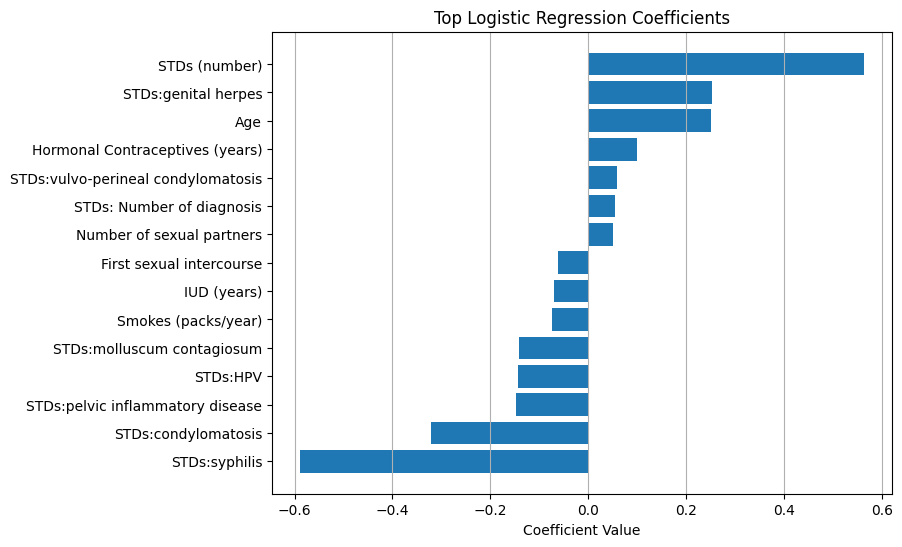

In [45]:
# Feature importance (Logistic Regression coefficients)
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]})

# Sort by absolute importance
coef_df["Abs_Coeff"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Abs_Coeff", ascending=False)
print(coef_df.head(15))

# Plot Top 15 Features
top_features = coef_df.head(15).sort_values("Coefficient")
plt.figure(figsize=(8,6))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.grid(axis='x')
plt.show()

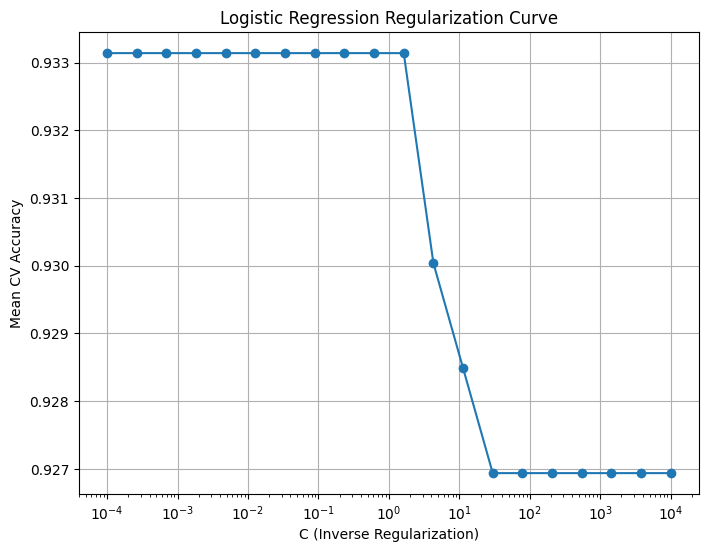

In [46]:
C_values = np.logspace(-4, 4, 20)
cv_accuracy = []
for c in C_values:
    model = LogisticRegression(
        C=c,
        max_iter=5000,
        random_state=42
    )
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='accuracy'
    )
    cv_accuracy.append(scores.mean())
plt.figure(figsize=(8,6))
plt.semilogx(C_values, cv_accuracy, marker='o')
plt.xlabel("C (Inverse Regularization)")
plt.ylabel("Mean CV Accuracy")
plt.title("Logistic Regression Regularization Curve")
plt.grid(True)
plt.show()

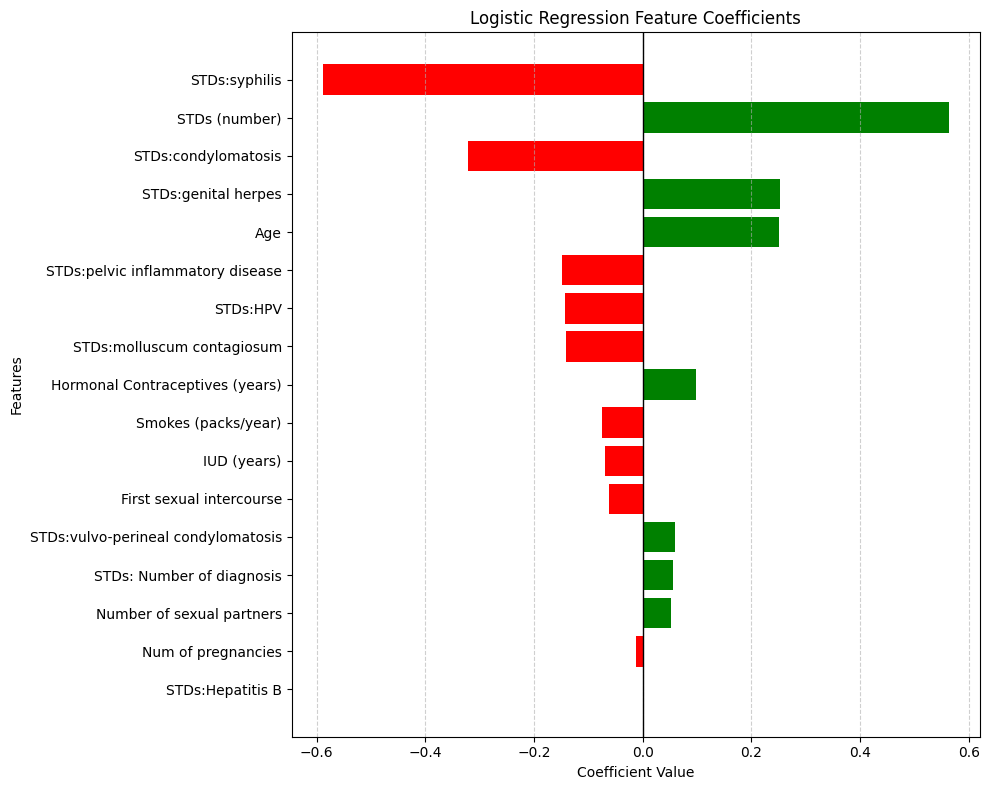

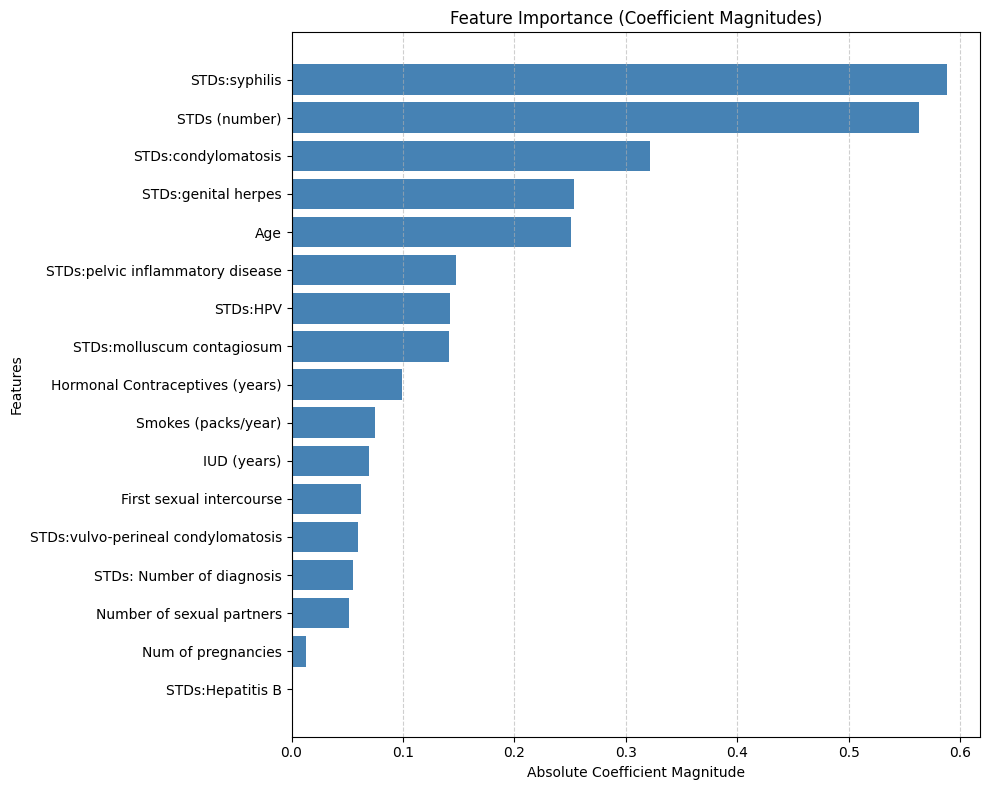

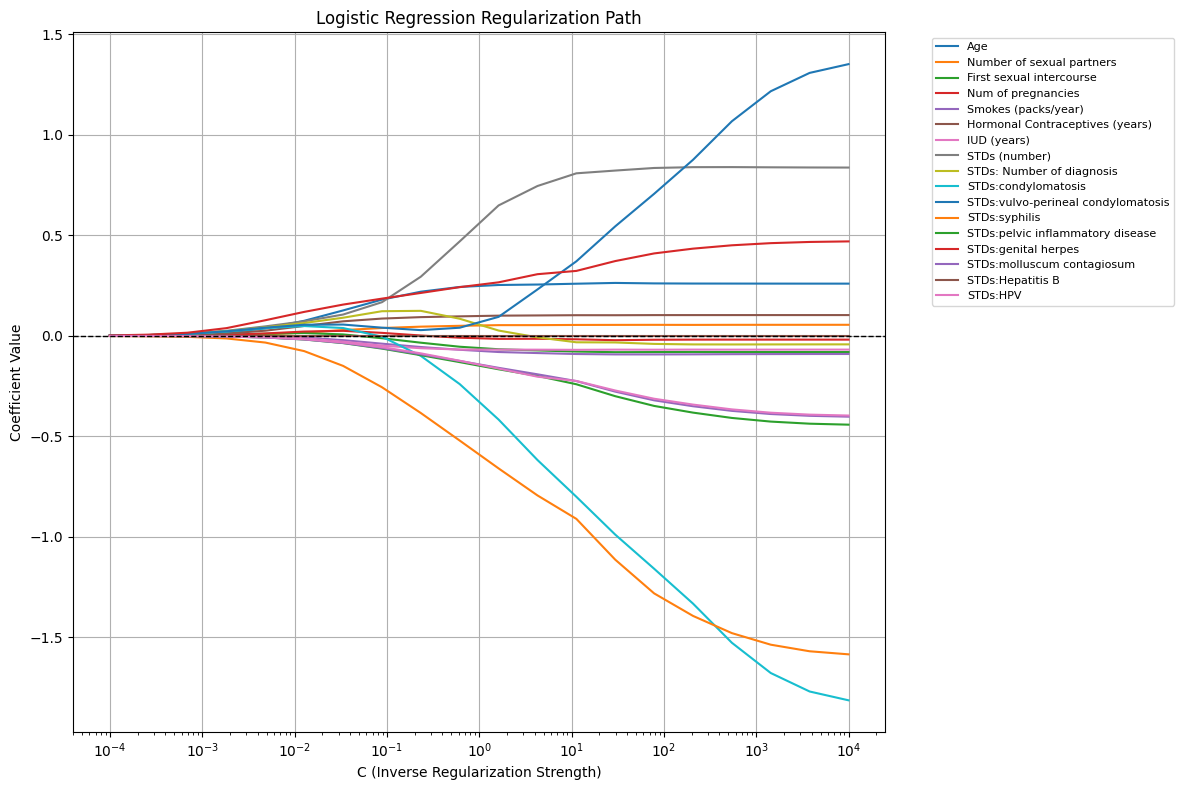

In [47]:
# Logistic Regression Coefficient Magnitude Plot

# Train the model
model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train_scaled, y_train)

# Create a DataFrame of coefficients
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]})

# Compute absolute coefficient values
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

# Sort by importance
coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False)

# Plot Signed Coefficients
colors = ["green" if x > 0 else "red" for x in coef_df["Coefficient"]]
plt.figure(figsize=(10, 8))
plt.barh(
    coef_df["Feature"],
    coef_df["Coefficient"],
    color=colors)

plt.axvline(x=0, color="black", linewidth=1)
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.title("Logistic Regression Feature Coefficients")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Plot Absolute Coefficient Magnitudes
plt.figure(figsize=(10, 8))
plt.barh(
    coef_df["Feature"],
    coef_df["Abs_Coefficient"],
    color="steelblue")

plt.xlabel("Absolute Coefficient Magnitude")
plt.ylabel("Features")
plt.title("Feature Importance (Coefficient Magnitudes)")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Regularization Path (Coefficient Shrinkage)
C_values = np.logspace(-4, 4, 20)
coef_path = []

for C in C_values:
    lr = LogisticRegression(
        C=C,
        max_iter=5000,
        random_state=42)
    lr.fit(X_train_scaled, y_train)
    coef_path.append(lr.coef_[0])
coef_path = np.array(coef_path)

plt.figure(figsize=(12, 8))
for i, feature in enumerate(X_train.columns):
    plt.semilogx(C_values, coef_path[:, i], label=feature)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("C (Inverse Regularization Strength)")
plt.ylabel("Coefficient Value")
plt.title("Logistic Regression Regularization Path")
plt.grid(True)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)
plt.tight_layout()
plt.show()